In [2]:
import pandas as pd
df=pd.read_csv("student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

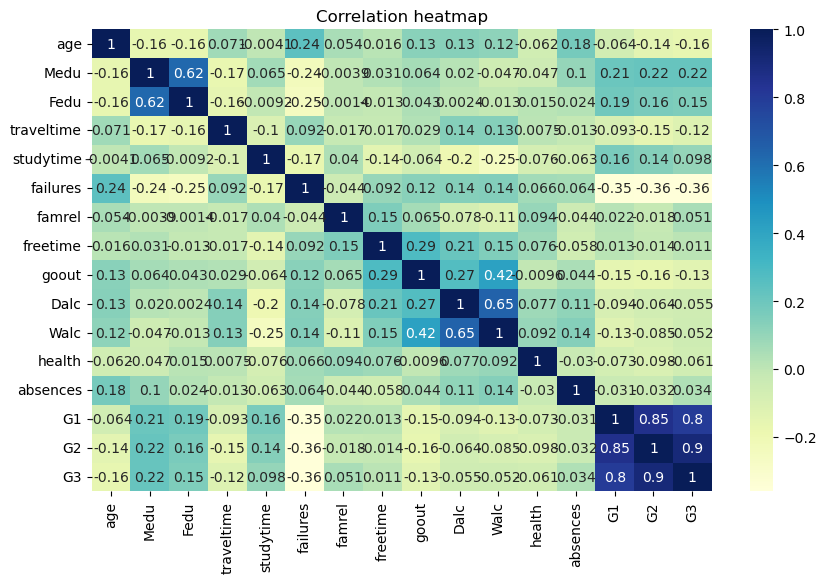

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
corr_matrix=df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,cmap='YlGnBu')
plt.title("Correlation heatmap")
plt.show()

In [12]:
df_final=pd.get_dummies(df,drop_first=True)
df_final.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [15]:
x=df_final.drop('G3',axis=1)
y=df_final['G3']

In [17]:
from sklearn.model_selection import train_test_split

# We split the data: 
# 80% goes to Training (X_train, y_train)
# 20% goes to Testing (X_test, y_test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Study Material (X_train):", X_train.shape)
print("Exam Paper (X_test):", X_test.shape)

Study Material (X_train): (316, 41)
Exam Paper (X_test): (79, 41)


In [18]:
from sklearn.linear_model import LinearRegression

# 1. Create the Robot's 'Brain'
model = LinearRegression()

# 2. The Study Session: We give it the clues (X_train) and the answers (y_train)
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# 1. The Robot takes the exam and makes guesses
predictions = model.predict(X_test)

# 2. Let's compare the first 5 Real Grades with the Robot's Guesses
import pandas as pd
results = pd.DataFrame({'Real Grade': y_test.iloc[:5], 'Robot Guess': predictions[:5]})
print(results)

     Real Grade  Robot Guess
78           10     6.001607
371          12    11.528478
248           5     2.866437
55           10     8.796631
390           9     8.553106


In [20]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)
print(f"📊 The Robot's Accuracy Score is: {score:.2f}")
#What's next for your Project?
#Now that you have your accuracy score, you have successfully:
#Cleaned the data.
#Analyzed patterns with a Heatmap.
#Translated words to numbers.
#Trained a Machine Learning model.
#Tested and Scored your model.

📊 The Robot's Accuracy Score is: 0.72


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


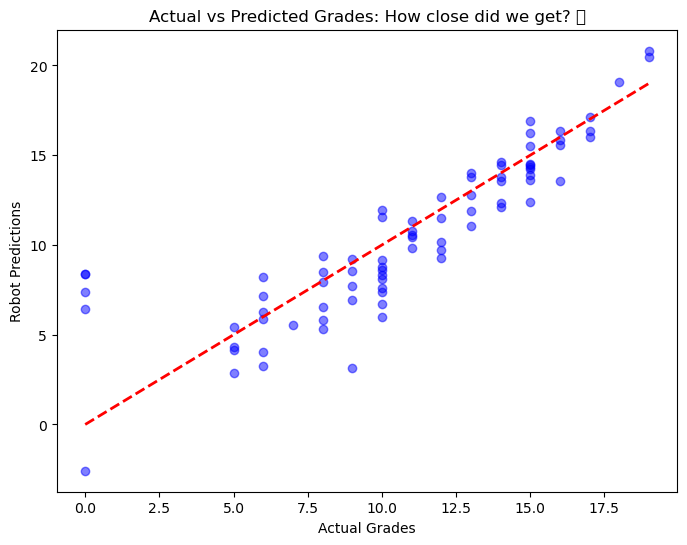

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Grades')
plt.ylabel('Robot Predictions')
plt.title('Actual vs Predicted Grades: How close did we get? 🎯')
plt.show()